In [1]:
# !pip install --upgrade pandas numpy scipy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


from pycaret.regression import *


# Data Prep


## Data Prep


In [ ]:
data_25_26 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
gw=22

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'opponent_team', 'was_home', 'xP', #'xP_next',
    'selected_by_percent','value', 'form', 'value_form',
    'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers', 'cbitr_volume_90', 'cbitr_probability',

    'elo', 'strength', 'strength_overall_home', 'strength_overall_away', 'strength_attack_home', 'strength_attack_away', 'strength_defence_home',
    'strength_defence_away', 'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'creativity_1', 'creativity_3', 'creativity_5', 'influence_1', 'influence_3', 'influence_5', 'threat_1', 'threat_3', 'threat_5', 'minutes_1', 'minutes_3',
        'minutes_5', 'pts_bonus_1', 'pts_bonus_3', 'pts_bonus_5', 'expected_goals_1', 'expected_goals_3',
        'expected_goals_5', 'expected_assists_1', 'expected_assists_3', 'expected_assists_5', 'xP_1', 'xP_3', 'xP_5', 'expected_goals_conceded_1',
        'expected_goals_conceded_3', 'expected_goals_conceded_5', 'goals_conceded_1', 'goals_conceded_3', 'goals_conceded_5', 'goals_scored_1', 'goals_scored_3',
        'goals_scored_5', 'shots_1', 'shots_3', 'shots_5', 'key_passes_1', 'key_passes_3', 'key_passes_5', 'npg_1', 'npg_3', 'npg_5', 'npxG_1', 'npxG_3', 'npxG_5',
        'goals_1', 'goals_3', 'goals_5', 'xG_1', 'xG_3', 'xG_5', 'xA_1', 'xA_3', 'xA_5', 'saves_1', 'saves_3', 'saves_5', 'starts_1', 'starts_3', 'starts_5',
        'yellow_cards_1', 'yellow_cards_3', 'yellow_cards_5', 'red_cards_1', 'red_cards_3', 'red_cards_5', 'assists_1', 'assists_3', 'assists_5', 'clean_sheets_1',
        'clean_sheets_3', 'clean_sheets_5', 'value_1', 'value_3', 'value_5', 'ict_index_1', 'ict_index_3', 'ict_index_5', 'selected_1', 'selected_3', 'selected_5',
        'transfers_in_1', 'transfers_in_3', 'transfers_in_5', 'transfers_out_1', 'transfers_out_3', 'transfers_out_5', 'ownership_change_1', 'ownership_change_3',
        'ownership_change_5', 'percenatge_net_transfers_1', 'percenatge_net_transfers_3', 'percenatge_net_transfers_5', 'xGChain_1', 'xGChain_3', 'xGChain_5',
        'xGBuildup_1', 'xGBuildup_3', 'xGBuildup_5', 'expected_goal_involvements_1', 'expected_goal_involvements_3', 'expected_goal_involvements_5', 'form_1', 'form_3',
        'form_5', 'clearances_blocks_interceptions_1', 'clearances_blocks_interceptions_3', 'clearances_blocks_interceptions_5', 'tackles_1', 'tackles_3', 'tackles_5',
        'recoveries_1', 'recoveries_3', 'recoveries_5', 'selected_by_percent_1',
        'selected_by_percent_3', 'selected_by_percent_5', 'strength_1', 'strength_3', 'strength_5', 'strength_overall_home_1', 'strength_overall_home_3',
        'strength_overall_home_5', 'strength_overall_away_1', 'strength_overall_away_3', 'strength_overall_away_5', 'strength_attack_home_1', 'strength_attack_home_3',
        'strength_attack_home_5', 'strength_attack_away_1', 'strength_attack_away_3', 'strength_attack_away_5', 'strength_defence_home_1', 'strength_defence_home_3',
        'strength_defence_home_5', 'strength_defence_away_1', 'strength_defence_away_3', 'strength_defence_away_5',

    'opp_elo', 'opp_clean_sheets', 'opp_strength']

data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)

data_25_26 = data_25_26[(data_25_26['minutes_3'] >= 15) ]

active_data = data_25_26[cols].copy()
active_data_ = active_data.copy()


CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
active_data_ = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)
active_data_

,fpl_id,round,fpl_name,team_id,was_home,xP,selected_by_percent,value,form,value_form,...,opponent_team_11.0,opponent_team_12.0,opponent_team_13.0,opponent_team_14.0,opponent_team_15.0,opponent_team_16.0,opponent_team_17.0,opponent_team_18.0,opponent_team_19.0,opponent_team_20.0
0,1.0,1,Raya,1.0,False,4.2,36.9,55.0,3.2,0.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,2,Raya,1.0,True,9.0,21.5,55.0,8.0,1.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,3,Raya,1.0,False,5.5,21.8,55.0,6.0,1.1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,4,Raya,1.0,True,6.5,23.5,55.0,6.0,1.1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,5,Raya,1.0,True,4.0,24.0,55.0,4.0,0.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6741,785.0,22,Pablo,19.0,False,0.0,0.0,55.0,0.5,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6745,789.0,22,Merrick,7.0,True,0.0,0.0,40.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6747,791.0,21,Taty,19.0,True,1.9,0.0,55.0,2.0,0.4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6748,791.0,22,Taty,19.0,False,0.0,0.0,55.0,2.0,0.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
def working_df(data, gw):
    GW_full = data['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['fpl_name'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names



def plot_preds(preds_df, position, gw):
    Y_test_names = preds_df[preds_df['position'] == position]['fpl_name'].values
    Y_test = preds_df[preds_df['position'] == position]['Actual_xP'].values
    Y_pred = preds_df[preds_df['position'] == position]['Pred_xP'].values

    # Convert names to positions on x-axis
    x = np.arange(len(Y_test_names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position(GW {gw})")
    plt.legend()
    plt.tight_layout()

    plt.show()

    # Index positions for players
    x = np.arange(len(Y_test_names))

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, Y_test, width, label='Actual Points')
    plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position(GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Calculate absolute errors
    errors = np.abs(Y_test - Y_pred)

    # Index for players
    x = np.arange(len(Y_test_names))
    width = 0.31  # width of the bars

    plt.figure(figsize=(16, 6))

    # Plot Actual and Predicted points side-by-side
    plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
    plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

    # Annotate absolute errors on top of predicted bars
    for i in range(len(Y_test_names)):
        plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

    # Labels and formatting
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.ylabel("Points")
    plt.title(f"{position}: Actual vs Predicted Points per Player (with Absolute Error) (GW {gw})")
    plt.legend()
    plt.tight_layout()

    plt.show()




## Predict


### GW 22


#### Train


,Description,Value
0,Session id,6900
1,Target,xP
2,Target type,Regression
3,Original data shape,"(3424, 208)"
4,Transformed data shape,"(3424, 144)"
5,Transformed train set shape,"(2739, 144)"
6,Transformed test set shape,"(685, 144)"
7,Numeric features,206
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.1638,0.0894,0.2890,0.9767,0.0918,0.1201,0.2980
gbr,Gradient Boosting Regressor,0.1643,0.1017,0.3121,0.9739,0.0937,0.1112,3.2270
lightgbm,Light Gradient Boosting Machine,0.1738,0.1195,0.3343,0.9694,0.0938,0.1133,54.4250
et,Extra Trees Regressor,0.1789,0.1158,0.3354,0.9704,0.1011,0.1208,3.0920
rf,Random Forest Regressor,0.2144,0.1426,0.3740,0.9639,0.1111,0.1462,6.1330
dt,Decision Tree Regressor,0.2539,0.2421,0.4881,0.9396,0.1440,0.1765,0.3170
ada,AdaBoost Regressor,0.3813,0.2740,0.5221,0.9312,0.1560,0.2562,1.5140
lr,Linear Regression,0.5027,0.4976,0.6680,0.8767,0.2166,0.3677,0.8030
en,Elastic Net,0.5030,0.4221,0.6487,0.8956,0.2145,0.4398,0.2960
llar,Lasso Least Angle Regression,0.5539,0.5058,0.7100,0.8752,0.2329,0.4903,0.3190


Ridge(random_state=6900)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

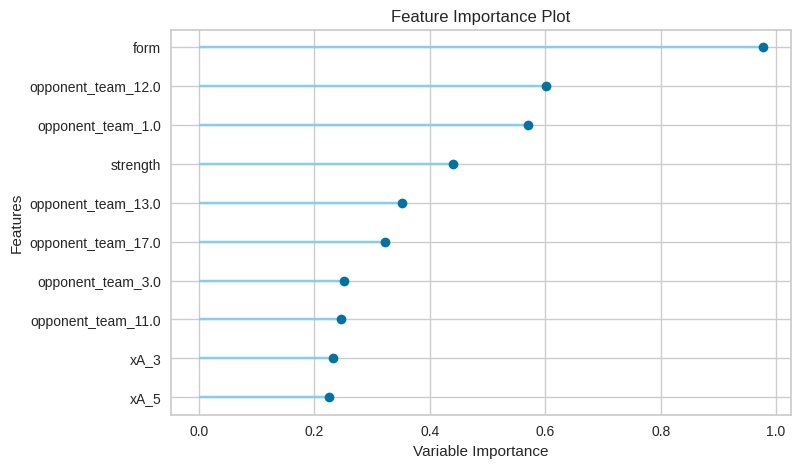

In [8]:
train_data, test_data, player_names = working_df(active_data_, 22)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features

                )

best_model_22 = base_model.compare_models(sort='MAE', n_select=1)
print(best_model_22)

evaluate_model(best_model_22)

plot_model(best_model_22, plot='feature')        # Feature importance

##### Tune Model


In [9]:
tuned = tune_model(best_model_22,
                #    verbose = False,   # This keeps the PyCaret grid visible
                   return_train_score = True,
                   optimize='MAE')

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


#### Predict


In [11]:
test_df = test_data.copy()
test_target = test_data['xP']
test_data_features = test_data.drop(columns=['xP'])

prediction_22 = predict_model(tuned, test_data_features)
prediction_22

,was_home,selected_by_percent,value,form,value_form,transfers_in,transfers_out,selected,ownership_change,percenatge_net_transfers,...,opponent_team_12.0,opponent_team_13.0,opponent_team_14.0,opponent_team_15.0,opponent_team_16.0,opponent_team_17.0,opponent_team_18.0,opponent_team_19.0,opponent_team_20.0,prediction_label
21,False,33.700001,59.0,3.3,0.6,3337464.0,1765731.0,4314992.0,25907.0,0.307990,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.398104
23,False,0.300000,39.0,0.0,0.0,31626.0,27294.0,38412.0,-12805.0,0.073523,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.954801
90,False,27.400000,63.0,4.3,0.7,5448707.0,2731103.0,3508332.0,48663.0,0.332233,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.456336
110,False,0.500000,51.0,0.3,0.1,325878.0,374701.0,64021.0,-15867.0,-0.069689,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.232882
153,False,2.500000,78.0,4.8,0.6,339442.0,485554.0,320103.0,7906.0,-0.177106,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.617705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6732,False,0.000000,45.0,0.0,0.0,663.0,219.0,0.0,0.0,0.503401,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.064816
6741,False,0.000000,55.0,0.5,0.1,1781.0,457.0,0.0,-1566.0,0.591600,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.539475
6745,True,0.000000,40.0,0.0,0.0,91.0,12.0,0.0,0.0,0.766990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.059032
6748,False,0.000000,55.0,2.0,0.4,1067.0,150.0,0.0,-350.0,0.753492,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.063811


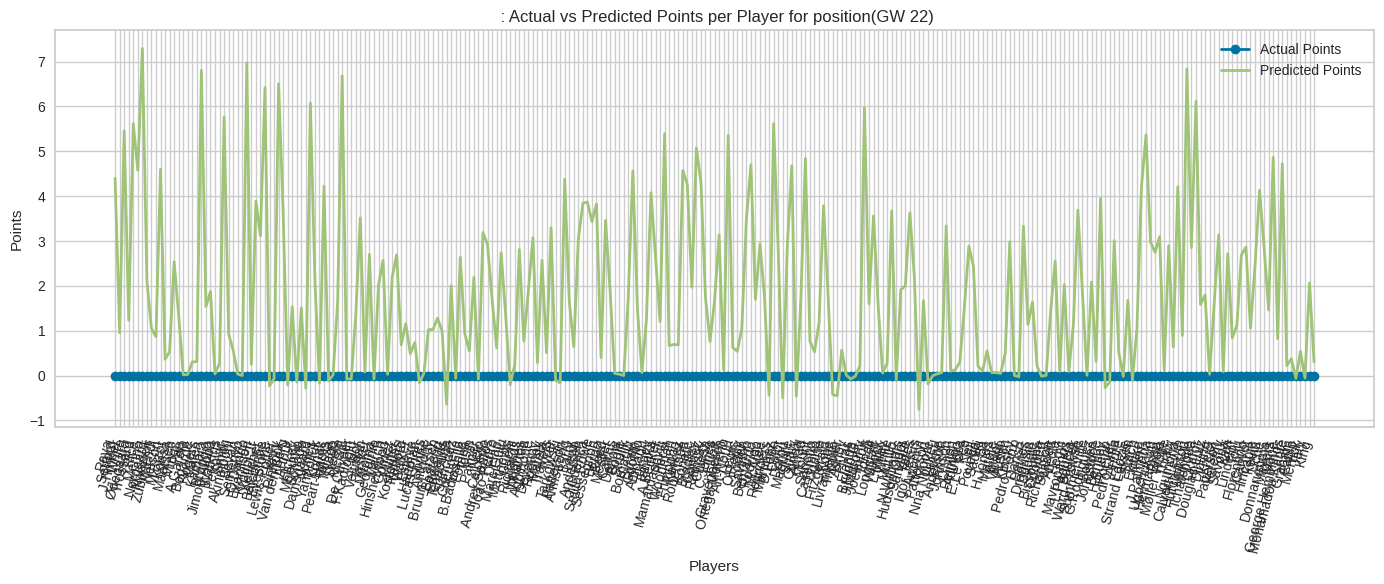

In [12]:
xp_actual = test_target
xp_pred = prediction_22['prediction_label'].values


# Convert names to positions on x-axis
x = np.arange(len(player_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, player_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title(f" : Actual vs Predicted Points per Player for position(GW 22)")
plt.legend()
plt.tight_layout()

plt.show()



# Current GW


## Train


,Description,Value
0,Session id,1498
1,Target,xP
2,Target type,Regression
3,Original data shape,"(6206, 208)"
4,Transformed data shape,"(6206, 132)"
5,Transformed train set shape,"(4964, 132)"
6,Transformed test set shape,"(1242, 132)"
7,Numeric features,206
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.1343,0.0755,0.2685,0.9805,0.0809,0.0934,42.5130
gbr,Gradient Boosting Regressor,0.1435,0.0738,0.2659,0.9810,0.0861,0.1025,3.2480
et,Extra Trees Regressor,0.1476,0.0852,0.2879,0.9780,0.0920,0.1003,4.1140
ridge,Ridge Regression,0.1498,0.0713,0.2606,0.9816,0.0879,0.1131,0.3920
rf,Random Forest Regressor,0.1696,0.0977,0.3080,0.9748,0.0979,0.1152,9.4070
dt,Decision Tree Regressor,0.2032,0.1926,0.4352,0.9504,0.1299,0.1313,0.5580
ada,AdaBoost Regressor,0.3851,0.2570,0.5061,0.9339,0.1595,0.2692,1.4700
en,Elastic Net,0.4933,0.4027,0.6336,0.8965,0.2107,0.4403,0.5260
lasso,Lasso Regression,0.5467,0.4913,0.6998,0.8738,0.2303,0.4936,0.5000
llar,Lasso Least Angle Regression,0.5469,0.4916,0.7000,0.8737,0.2303,0.4937,0.4410


LGBMRegressor(n_jobs=-1, random_state=1498)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

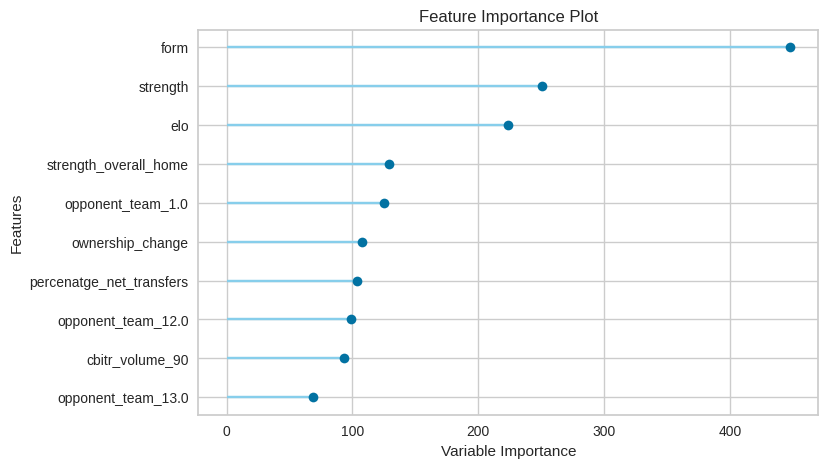

In [7]:
train_data, test_data, player_names = working_df(active_data_, 22)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features

                )

best_model_22 = base_model.compare_models(sort='MAE', n_select=1)
print(best_model_22)

evaluate_model(best_model_22)

plot_model(best_model_22, plot='feature')        # Feature importance

In [8]:
train_data, test_data, player_names = working_df(active_data_, 22)
test_df = test_data.copy()
test_target = test_data['xP']
test_data_features = test_data.drop(columns=['xP'])

prediction_22 = predict_model(best_model_22, test_data_features)
prediction_22['names'] = player_names
prediction_22[['prediction_label', 'names']].sort_values(by='prediction_label', ascending=False) #.head(10).round(2).to_string(index=False)

,prediction_label,names
947,7.632093,Collins
3922,7.198561,Haaland
222,7.053746,Rice
3459,6.817737,Wirtz
137,6.810489,Saka
...,...,...
3878,-0.233626,McAtee
4654,-0.260381,Boly
5991,-0.267746,Gunn
4653,-0.308534,Abbott


#### Optimize


In [9]:
squad_22, total_points_22 = get_optimized_team(Y_pred_22, 22)
squad_22

NameError: name 'get_optimized_team' is not defined